# Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час.

Целевая метрика — **RMSE** на тестовой выборке должна быть не больше **48**. Тестовая выборка — 10% от исходных данных.

## План исследования

1) Загрузка данных и ресемплирование по одному часу
2) Исследовательский анализ данных (тренд и сезонность)
3) Формирование признаков
4) Корреляционный анализ признаков
5) Обучение моделей и подбор гиперпараметров
6) Тестирование лучшей модели
7) Общий вывод

## Загрузка данных

### Импорт модулей

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import phik
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

/home/aiagent/miniconda3/envs/practicum/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


/home/aiagent/miniconda3/envs/practicum/lib/python3.9/site-packages/sklearn/utils/fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


### Определение констант

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.1
VALID_SIZE = 0.2
MAX_RMSE = 48
MAX_LAG = 24
ROLLING_SIZE = 24

Загрузим данные и сразу преобразуем столбец с датой в индекс типа `datetime`.

In [3]:
try:
    data = pd.read_csv('./source/taxi.csv', index_col=[0], parse_dates=[0])
except FileNotFoundError:
    data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

data = data.sort_index()
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Данные охватывают период с марта по август 2018 года, шаг наблюдений — 10 минут. Проверим, что индекс монотонно возрастает, и убедимся в отсутствии пропусков.

In [4]:
print('Индекс монотонно возрастает:', data.index.is_monotonic_increasing)
print('Период:', data.index.min(), '—', data.index.max())
print('Пропусков:', data['num_orders'].isna().sum())

Индекс монотонно возрастает: True
Период: 2018-03-01 00:00:00 — 2018-08-31 23:50:00
Пропусков: 0


Индекс упорядочен и не содержит пропусков. По условию задачи ресемплируем данные по одному часу — суммируем число заказов внутри каждого часа.

In [5]:
data = data.resample('1H').sum()
print('Размер после ресемплирования:', data.shape)
data.head()

Размер после ресемплирования: (4416, 1)


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


После ресемплирования получили 4416 почасовых наблюдений без пропусков. Переходим к анализу.

## Исследовательский анализ данных

Построим график всего временного ряда.

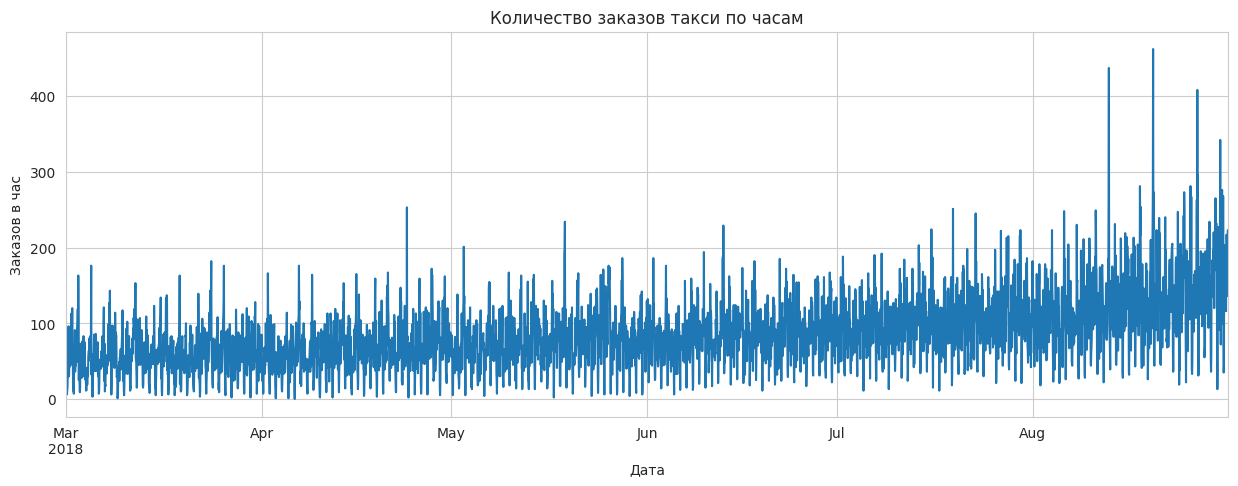

In [6]:
plt.figure(figsize=(15, 5))
data['num_orders'].plot()
plt.title('Количество заказов такси по часам')
plt.xlabel('Дата')
plt.ylabel('Заказов в час')
plt.show()

На графике заметен восходящий тренд: со временем заказов становится больше. Также виден высокочастотный колебательный паттерн — вероятно, суточная сезонность. Рассмотрим описательную статистику.

In [7]:
data['num_orders'].describe()

count    4416.000000
mean       84.422781
std        45.023853
min         0.000000
25%        54.000000
50%        78.000000
75%       107.000000
max       462.000000
Name: num_orders, dtype: float64

В среднем за час поступает около 84 заказов, максимум — 462. Чтобы разглядеть суточную и недельную сезонность, посмотрим на ряд за две недели.

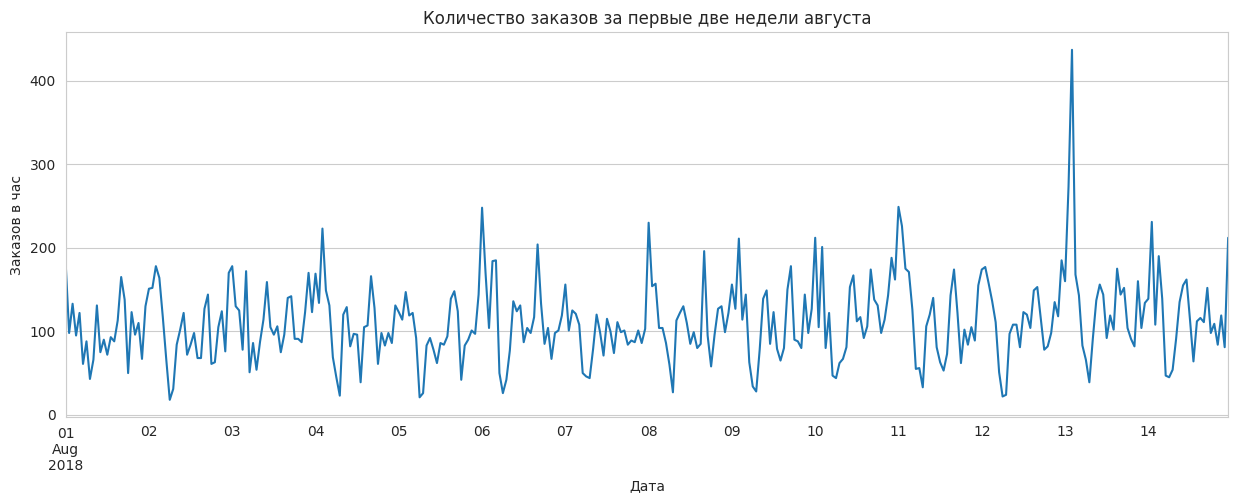

In [8]:
plt.figure(figsize=(15, 5))
data['num_orders']['2018-08-01':'2018-08-14'].plot()
plt.title('Количество заказов за первые две недели августа')
plt.xlabel('Дата')
plt.ylabel('Заказов в час')
plt.show()

Видна выраженная суточная сезонность: ночью заказов минимум, в течение дня — рост с пиками. Просматривается и недельный ритм. Разложим ряд на тренд, сезонность и остатки с суточным периодом (24 часа).

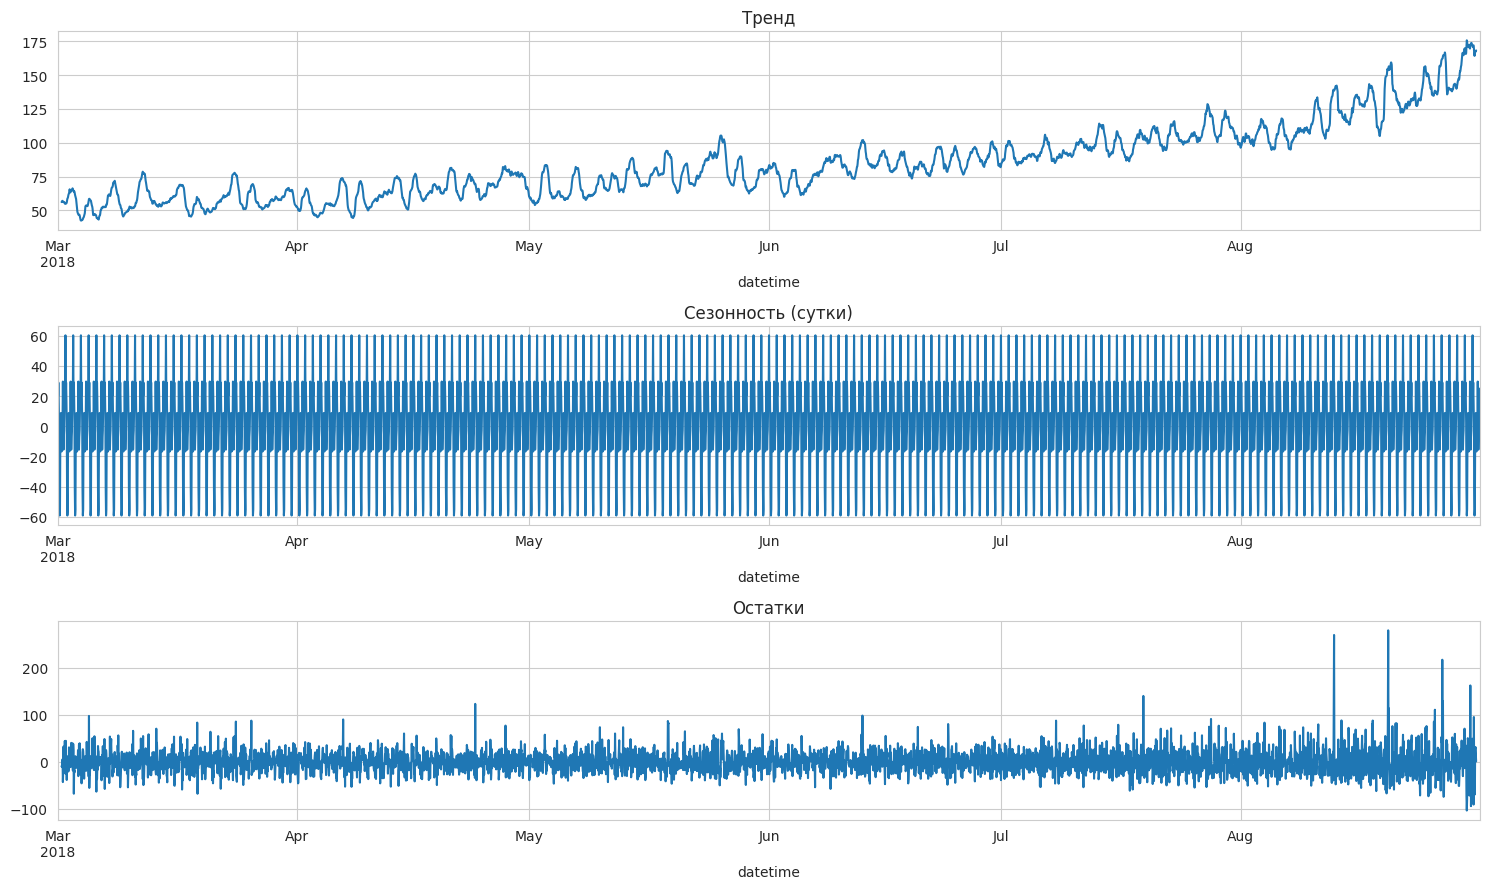

In [9]:
decomposed = seasonal_decompose(data['num_orders'], period=24)

fig, axes = plt.subplots(3, 1, figsize=(15, 9))
decomposed.trend.plot(ax=axes[0], title='Тренд')
decomposed.seasonal.plot(ax=axes[1], title='Сезонность (сутки)')
decomposed.resid.plot(ax=axes[2], title='Остатки')
plt.tight_layout()
plt.show()

Тренд устойчиво растёт на всём периоде. Чтобы внимательнее рассмотреть форму суточной сезонности, выведем её за несколько дней.

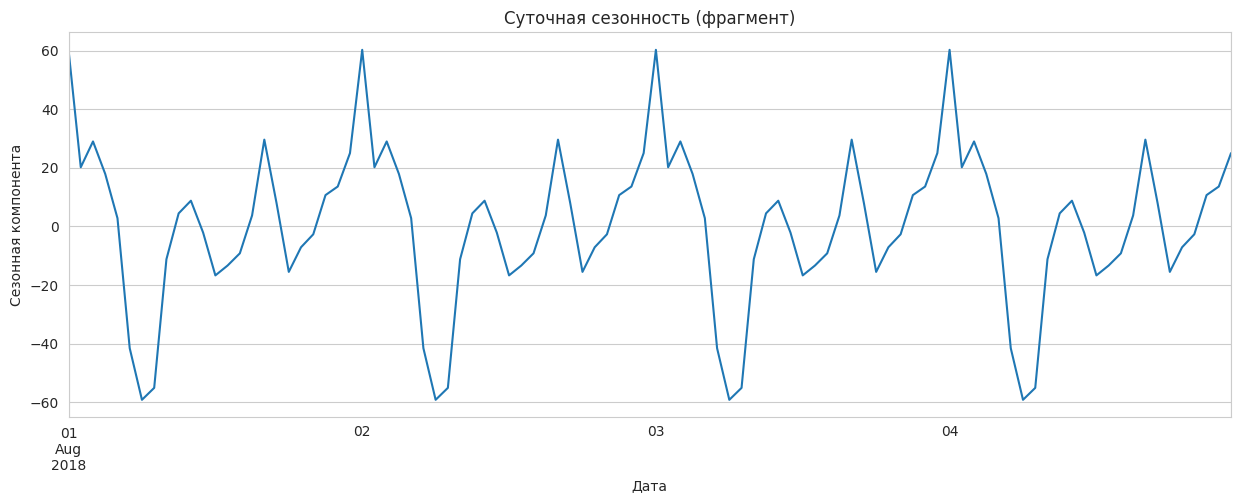

In [10]:
plt.figure(figsize=(15, 5))
decomposed.seasonal['2018-08-01':'2018-08-04'].plot()
plt.title('Суточная сезонность (фрагмент)')
plt.xlabel('Дата')
plt.ylabel('Сезонная компонента')
plt.show()

Внутри суток наблюдается провал ночью и подъём ближе к полуночи. Паттерн стабильно повторяется изо дня в день.

### Выводы EDA

- Ряд **нестационарен**: присутствует выраженный восходящий тренд.
- Есть устойчивая **суточная сезонность** и более слабый **недельный** ритм.
- Значит, для модели полезны календарные признаки (час, день недели), **отстающие признаки** (лаги) и **скользящее среднее**, которые позволят учесть тренд и сезонность.

## Формирование признаков

Создадим функцию, которая добавляет к ряду календарные признаки, лаги и скользящее среднее. Скользящее среднее считаем по сдвинутому ряду, чтобы не использовать значение текущего часа и не допустить утечки целевого признака.

In [11]:
def make_features(df, max_lag, rolling_size):
    df = df.copy()
    df['month'] = df.index.month
    df['dayofweek'] = df.index.dayofweek
    df['hour'] = df.index.hour
    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)
    df['rolling_mean'] = df['num_orders'].shift().rolling(rolling_size).mean()
    return df

Глубину лагов и окно скользящего среднего возьмём равными суткам — 24 часа, так мы учтём суточную сезонность. После создания признаков удалим первые строки с пропусками от лагов.

In [12]:
data = make_features(data, MAX_LAG, ROLLING_SIZE)
data = data.dropna()
print('Размер после формирования признаков:', data.shape)
data.head()

Размер после формирования признаков: (4392, 29)


,num_orders,month,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,3,4,0,58.0,113.0,66.0,61.0,45.0,73.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,56.833333
2018-03-02 01:00:00,120,3,4,1,90.0,58.0,113.0,66.0,61.0,45.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,55.416667
2018-03-02 02:00:00,75,3,4,2,120.0,90.0,58.0,113.0,66.0,61.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,56.875000
2018-03-02 03:00:00,64,3,4,3,75.0,120.0,90.0,58.0,113.0,66.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,57.041667
2018-03-02 04:00:00,20,3,4,4,64.0,75.0,120.0,90.0,58.0,113.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,56.958333


## Корреляционный анализ

Оценим связь признаков с целевым и между собой. Используем коэффициент **phik** — он улавливает в том числе нелинейные зависимости и работает со смешанными типами признаков. Возьмём целевой признак, скользящее среднее, несколько характерных лагов и календарные признаки.

/home/aiagent/miniconda3/envs/practicum/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/aiagent/miniconda3/envs/practicum/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/aiagent/miniconda3/envs/practicum/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/aiagent/miniconda3/envs/practicum/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this vers

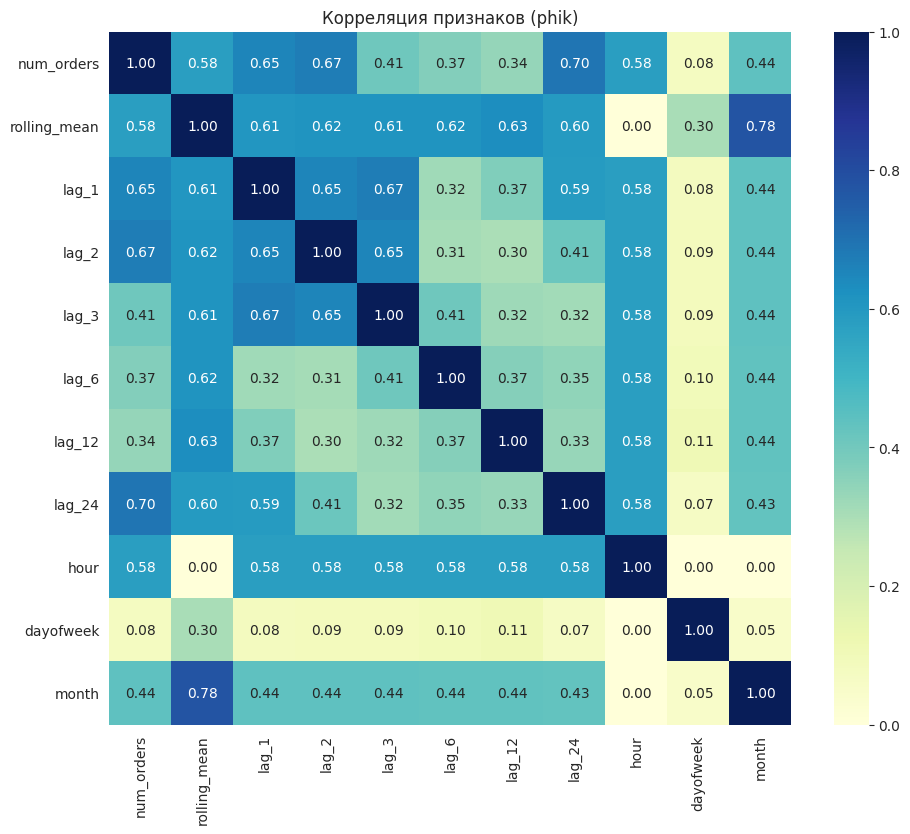

In [13]:
corr_features = ['num_orders', 'rolling_mean', 'lag_1', 'lag_2', 'lag_3',
                 'lag_6', 'lag_12', 'lag_24', 'hour', 'dayofweek', 'month']
interval_cols = ['num_orders', 'rolling_mean', 'lag_1', 'lag_2', 'lag_3',
                 'lag_6', 'lag_12', 'lag_24']

phi_k = data[corr_features].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(11, 9))
ax = plt.axes()
sns.heatmap(phi_k, cmap='YlGnBu', annot=True, fmt='.2f')
ax.set_title('Корреляция признаков (phik)')
plt.show()

Отдельно посмотрим, насколько каждый признак связан с целевым.

In [14]:
phi_k['num_orders'].sort_values(ascending=False)

num_orders      1.000000
lag_24          0.695203
lag_2           0.673129
lag_1           0.653149
rolling_mean    0.580252
hour            0.578914
month           0.439223
lag_3           0.409149
lag_6           0.367626
lag_12          0.336394
dayofweek       0.077363
Name: num_orders, dtype: float64

Выводы корреляционного анализа:

- Сильнее всего с числом заказов связан **lag_24** (phik ≈ 0.70) — число заказов в тот же час сутки назад. Это прямое подтверждение суточной сезонности.
- Заметно связаны недавние лаги **lag_1, lag_2** (≈ 0.65) и **скользящее среднее** (≈ 0.58): ряд инерционен.
- Признаки **hour** (≈ 0.58) и **month** (≈ 0.44) отражают суточную сезонность и растущий тренд соответственно.
- **dayofweek** связан с целевым слабо (≈ 0.08) — выраженной недельной сезонности нет.
- Лаги сильно коррелируют между собой (мультиколлинеарность), поэтому из линейных моделей разумно брать регуляризованные — гребневую регрессию и Лассо.

## Обучение моделей

Разделим данные **без перемешивания** — для временного ряда порядок наблюдений важен. Сначала отделим тестовую выборку (последние 10%), затем из оставшихся данных выделим валидационную (последние 20%) для подбора гиперпараметров.

In [15]:
train_valid, test = train_test_split(data, shuffle=False, test_size=TEST_SIZE)
train, valid = train_test_split(train_valid, shuffle=False, test_size=VALID_SIZE)

features_train, target_train = train.drop('num_orders', axis=1), train['num_orders']
features_valid, target_valid = valid.drop('num_orders', axis=1), valid['num_orders']
features_test, target_test = test.drop('num_orders', axis=1), test['num_orders']
features_tv, target_tv = train_valid.drop('num_orders', axis=1), train_valid['num_orders']

print('Обучающая:    ', features_train.shape, '|', train.index.min(), '—', train.index.max())
print('Валидационная:', features_valid.shape, '|', valid.index.min(), '—', valid.index.max())
print('Тестовая:     ', features_test.shape, '|', test.index.min(), '—', test.index.max())

Обучающая:     (3161, 28) | 2018-03-02 00:00:00 — 2018-07-11 16:00:00
Валидационная: (791, 28) | 2018-07-11 17:00:00 — 2018-08-13 15:00:00
Тестовая:      (440, 28) | 2018-08-13 16:00:00 — 2018-08-31 23:00:00


Заведём вспомогательные функции: RMSE и обучение модели с масштабированием признаков (масштабатор обучаем только на обучающей части, чтобы не было утечки).

In [16]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)

def scale_fit_predict(model, X_fit, y_fit, X_eval):
    scaler = StandardScaler().fit(X_fit)
    model.fit(scaler.transform(X_fit), y_fit)
    return model.predict(scaler.transform(X_eval))

В качестве **базовой модели** возьмём наивный прогноз: предсказание заказов предыдущим часом (признак `lag_1`). Это ориентир, который должны превзойти полноценные модели.

In [17]:
baseline_rmse = rmse(target_test, features_test['lag_1'])
print('RMSE базовой модели (предыдущий час):', round(baseline_rmse, 2))

RMSE базовой модели (предыдущий час): 58.88


Обучим несколько классических моделей регрессии и подберём их гиперпараметры по валидационной выборке. По выводам корреляционного анализа из линейных моделей берём регуляризованные — Ridge и Lasso. Каждую модель перебираем по сетке параметров и оставляем конфигурацию с наименьшим RMSE на валидации.

In [18]:
models = {
    'Ridge': (Ridge(random_state=RANDOM_STATE), {'alpha': [0.1, 1, 10, 100]}),
    'Lasso': (Lasso(random_state=RANDOM_STATE), {'alpha': [0.01, 0.1, 1, 10]}),
    'DecisionTree': (DecisionTreeRegressor(random_state=RANDOM_STATE),
                     {'max_depth': [4, 6, 8, 10, 12]}),
    'RandomForest': (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                     {'n_estimators': [100, 200], 'max_depth': [8, 12, 16]}),
    'GradientBoosting': (GradientBoostingRegressor(random_state=RANDOM_STATE),
                         {'n_estimators': [100, 200], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]}),
}

In [19]:
valid_rmse = {}
best_params = {}

for name, (estimator, param_grid) in models.items():
    best_rmse, best_p = float('inf'), None
    for params in ParameterGrid(param_grid):
        candidate = clone(estimator).set_params(**params)
        pred = scale_fit_predict(candidate, features_train, target_train, features_valid)
        score = rmse(target_valid, pred)
        if score < best_rmse:
            best_rmse, best_p = score, params
    valid_rmse[name] = best_rmse
    best_params[name] = best_p
    print('{:16s} RMSE(valid)={:.2f}  параметры={}'.format(name, best_rmse, best_p))

Ridge            RMSE(valid)=33.14  параметры={'alpha': 100}
Lasso            RMSE(valid)=33.19  параметры={'alpha': 0.01}


DecisionTree     RMSE(valid)=38.33  параметры={'max_depth': 6}


RandomForest     RMSE(valid)=33.14  параметры={'max_depth': 16, 'n_estimators': 200}


GradientBoosting RMSE(valid)=33.61  параметры={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


Сведём результаты по валидации в таблицу и сравним модели.

In [20]:
results = pd.DataFrame({'RMSE_valid': valid_rmse}).sort_values('RMSE_valid')
results

,RMSE_valid
RandomForest,33.135249
Ridge,33.144302
Lasso,33.188134
GradientBoosting,33.613196
DecisionTree,38.326290


Выберем модель с наименьшим RMSE на валидации.

In [21]:
best_name = results.index[0]
best_model = clone(models[best_name][0]).set_params(**best_params[best_name])
print('Лучшая модель по валидации:', best_name, '|', best_params[best_name])

Лучшая модель по валидации: RandomForest | {'max_depth': 16, 'n_estimators': 200}


## Тестирование лучшей модели

Обучим выбранную модель на объединённой обучающей и валидационной выборке и оценим её на тестовой. Сравним результат с базовой моделью.

In [22]:
test_pred = scale_fit_predict(best_model, features_tv, target_tv, features_test)
test_rmse = rmse(target_test, test_pred)

print('Модель:              ', best_name)
print('RMSE на тесте:       {:.2f}'.format(test_rmse))
print('RMSE базовой модели: {:.2f}'.format(baseline_rmse))
print('Условие RMSE <= {} выполнено:'.format(MAX_RMSE), test_rmse <= MAX_RMSE)

Модель:               RandomForest
RMSE на тесте:       43.04
RMSE базовой модели: 58.88
Условие RMSE <= 48 выполнено: True


Сравним прогноз с фактическими значениями на тестовой выборке.

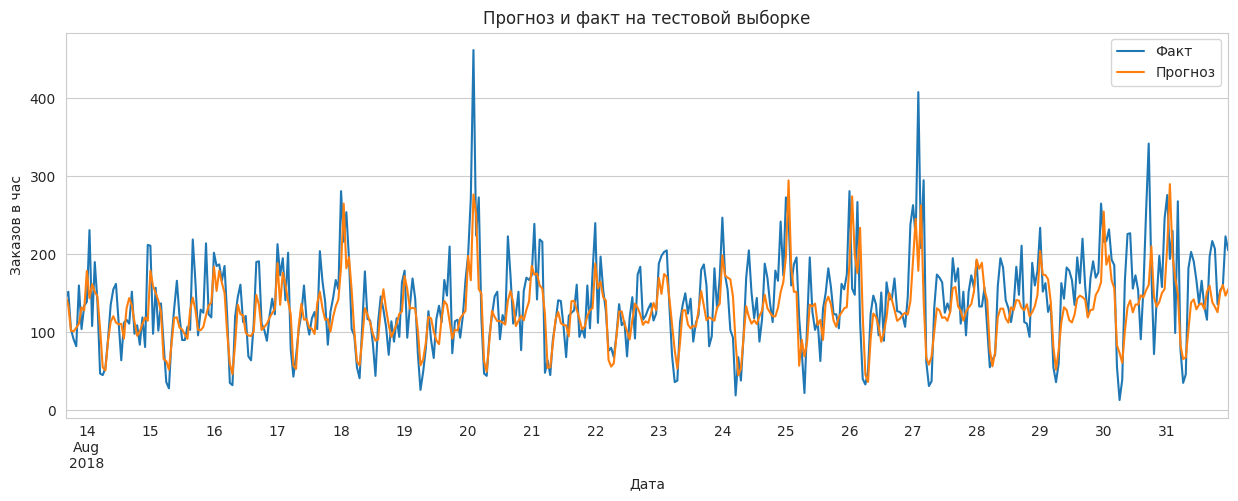

In [23]:
plt.figure(figsize=(15, 5))
target_test.plot(label='Факт')
pd.Series(test_pred, index=target_test.index).plot(label='Прогноз')
plt.title('Прогноз и факт на тестовой выборке')
plt.xlabel('Дата')
plt.ylabel('Заказов в час')
plt.legend()
plt.show()

Модель уверенно превосходит базовый прогноз и улавливает суточную сезонность ряда.

## Общий вывод

- Исходные данные о заказах такси (март–август 2018 года, шаг 10 минут) были ресемплированы по одному часу — получили 4416 наблюдений без пропусков.
- Анализ показал восходящий тренд и выраженную суточную сезонность, поэтому в признаки добавлены календарные значения, лаги за сутки и скользящее среднее.
- Корреляционный анализ (phik) подтвердил: сильнее всего с целевым связаны `lag_24`, недавние лаги и скользящее среднее; лаги сильно коррелируют между собой, что оправдывает выбор регуляризованных линейных моделей.
- Сравнили базовую модель (наивный прогноз предыдущим часом, RMSE ≈ 58.9 на тесте) и пять классических моделей регрессии с подбором гиперпараметров на валидационной выборке. Лучшей оказалась модель случайного леса.
- На тестовой выборке выбранная модель показала **RMSE ≈ 43.0** — ниже требуемого порога 48, то есть требование задачи выполнено.
- Модель можно использовать для прогноза числа заказов на следующий час и заблаговременного привлечения водителей в пиковые часы.